<a href="https://colab.research.google.com/github/tinana2k/CS-5530---Tina-Nguyen/blob/main/Assignment_1_Q2_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q2: Data Visualization**
===================================================================

## **Perform the 5 data visualization tasks (given below) on the student performance dataset given in the link below. Each figure: 800×600 px, 300 DPI, title, labeled axes/units, legend if applicable, readable ticks.**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### **Stage 1: Ingest**

In [3]:
# Stage 1: Ingest
# Read raw data from GitHub into a DataFrame

df = pd.read_csv(
    "https://raw.githubusercontent.com/tinana2k/CS-5530---Tina-Nguyen/main/Assignments/Assignment%201/Q2_Data_Visualization/data_raw/StudentsPerformance.csv"
)

print("--- Stage 1: Ingest Complete ---")
print(df.head())
print("\n" + "="*40 + "\n")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

--- Stage 1: Ingest Complete ---
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


Shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'm

### **Stage 2: Process**

In [4]:
# Stage 2: Process
print("--- Stage 2: Process Initiated ---")

# Standardize column names for coding (keep meaning same)
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("/", "_")
)

# Rename to short names (optional but makes plotting easier)
df.rename(columns={
    "parental_level_of_education": "parent_edu",
    "test_preparation_course": "test_prep",
    "math_score": "math",
    "reading_score": "reading",
    "writing_score": "writing"
}, inplace=True)

# Add average score
df["avg_score"] = df[["math", "reading", "writing"]].mean(axis=1).round(2)

# Save clean data (NO process_data.csv)
Path("clean_data").mkdir(exist_ok=True)
df.to_csv("clean_data/clean_StudentPerformance.csv", index=False)

print("Saved: clean_data/clean_StudentPerformance.csv")
print("Columns now:", df.columns.tolist())
print(df.head())

--- Stage 2: Process Initiated ---
Saved: clean_data/clean_StudentPerformance.csv
Columns now: ['gender', 'race_ethnicity', 'parent_edu', 'lunch', 'test_prep', 'math', 'reading', 'writing', 'avg_score']
   gender race_ethnicity          parent_edu         lunch  test_prep  math  \
0  female        group B   bachelor's degree      standard       none    72   
1  female        group C        some college      standard  completed    69   
2  female        group B     master's degree      standard       none    90   
3    male        group A  associate's degree  free/reduced       none    47   
4    male        group C        some college      standard       none    76   

   reading  writing  avg_score  
0       72       74      72.67  
1       90       88      82.33  
2       95       93      92.67  
3       57       44      49.33  
4       78       75      76.33  


### **Stage 3: Visualization**

In [5]:
Path("results").mkdir(exist_ok=True)
print("--- Stage 3: Analyze Initiated ---")

--- Stage 3: Analyze Initiated ---


**A. V1 — Gender boxplots (math vs reading) (2 pts)**

a. Question: Are there gender differences in math vs reading?

b. Chart: Side‑by‑side boxplots of math score and reading score grouped by gender.


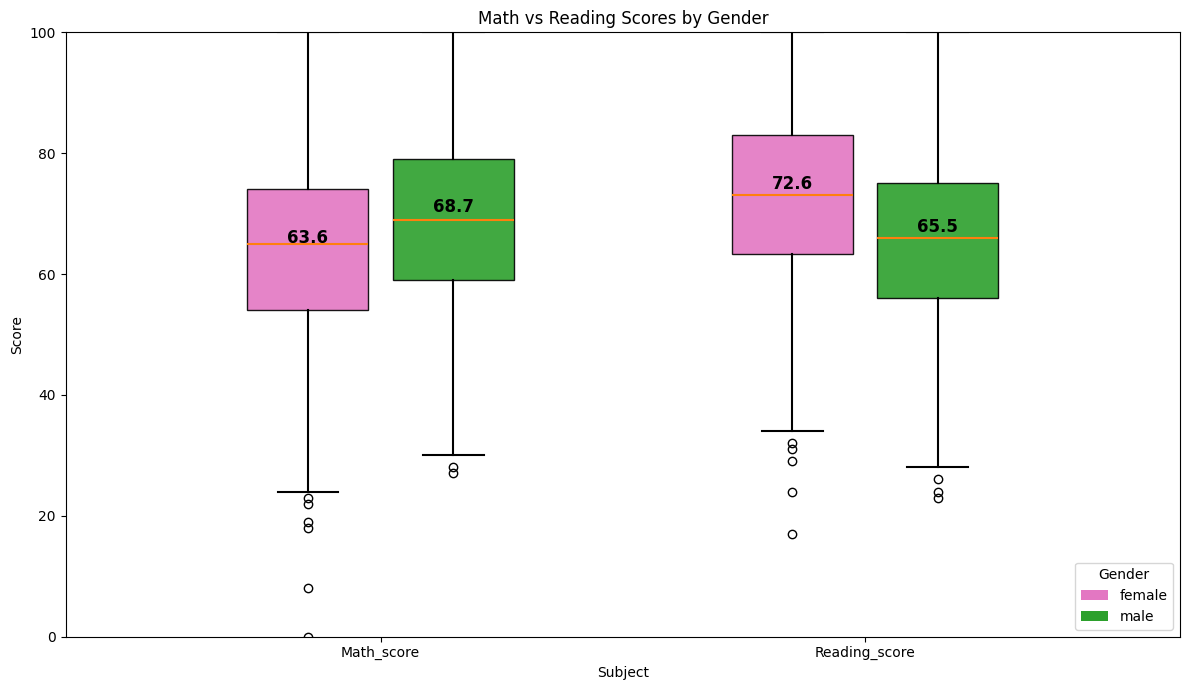

Saved: results/V1_Gender_Boxplots.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

Path("results").mkdir(exist_ok=True)

# --- Choose correct column names automatically ---
math_col = "math" if "math" in df.columns else "math_score"
read_col = "reading" if "reading" in df.columns else "reading_score"

# --- Split data by gender ---
f_math = df.loc[df["gender"] == "female", math_col].dropna()
m_math = df.loc[df["gender"] == "male",   math_col].dropna()
f_read = df.loc[df["gender"] == "female", read_col].dropna()
m_read = df.loc[df["gender"] == "male",   read_col].dropna()

# --- Build side-by-side boxplots for each subject ---
data = [f_math, m_math, f_read, m_read]
positions = [0.85, 1.15, 1.85, 2.15]
width = 0.25

plt.figure(figsize=(12, 7))
bp = plt.boxplot(
    data,
    positions=positions,
    widths=width,
    patch_artist=True,
    showfliers=True
)

# Colors
colors = ["tab:pink", "tab:green", "tab:pink", "tab:green"]
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c)
    box.set_alpha(0.9)

# Style lines
for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_linewidth(1.5)

# ---------- ADD MEAN NUMBERS ----------
means = [np.mean(d) for d in data]

for pos, mean in zip(positions, means):
    plt.text(
        pos,
        mean + 1.5,            # small offset above box
        f"{mean:.1f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# X axis labels
plt.xticks([1, 2], ["Math_score", "Reading_score"])
plt.xlabel("Subject")
plt.ylabel("Score")
plt.title("Math vs Reading Scores by Gender")

# Legend
legend_handles = [
    Patch(facecolor="tab:pink", label="female"),
    Patch(facecolor="tab:green", label="male"),
]
plt.legend(handles=legend_handles, title="Gender", loc="lower right")

plt.ylim(0, 100)
plt.tight_layout()

plt.savefig("results/V1_Gender_Boxplots.png")
plt.show()

print("Saved: results/V1_Gender_Boxplots.png")

**B. V2 — Test prep impact on math (2 pts)**

a. Question: Do students who completed test prep score higher in math?

b. Chart: Any chart of your choice for math score by test preparation course
(completed vs none).

Using columns: {'prep_col': 'test_prep', 'math_col': 'math'}


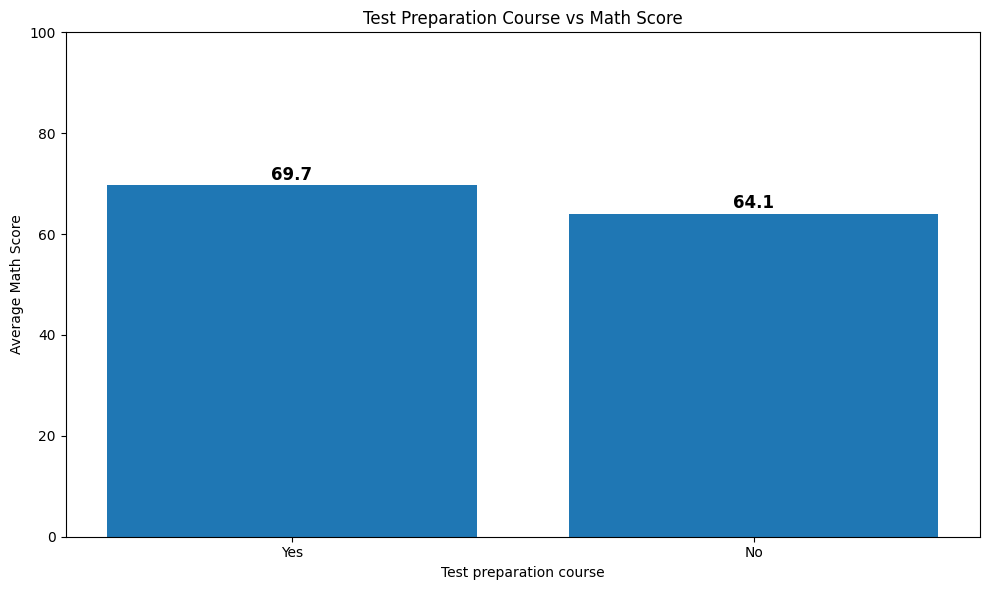

Saved → results/V2_Test_prep_impact_on_math.png


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("results").mkdir(exist_ok=True)

# --- Normalize column names (safe) ---
df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_")

# --- Auto-detect columns ---
math_col = "math" if "math" in df.columns else "math_score"

# pick whichever exists
if "test_prep" in df.columns:
    prep_col = "test_prep"
elif "test_preparation_course" in df.columns:
    prep_col = "test_preparation_course"
elif "test_preparation" in df.columns:
    prep_col = "test_preparation"
else:
    # fallback: try to find a column containing both "test" and "prep"
    candidates = [c for c in df.columns if ("test" in c and "prep" in c)]
    if not candidates:
        raise KeyError(f"Can't find test prep column. Available columns: {df.columns.tolist()}")
    prep_col = candidates[0]

print("Using columns:", {"prep_col": prep_col, "math_col": math_col})

# --- Compute averages ---
avg_scores = df.groupby(prep_col)[math_col].mean().sort_index()

# Optional: display as No/Yes if values are none/completed
# (only changes labels, not data)
label_map = {"none": "No", "completed": "Yes"}
labels = [label_map.get(str(x), str(x)) for x in avg_scores.index]
values = avg_scores.values

# --- Plot ---
plt.figure(figsize=(10,6))
bars = plt.bar(labels, values)

# --- Add numbers on bars ---
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f"{h:.1f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Test Preparation Course vs Math Score")
plt.xlabel("Test preparation course")
plt.ylabel("Average Math Score")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("results/V2_Test_prep_impact_on_math.png", dpi=300)
plt.show()

print("Saved → results/V2_Test_prep_impact_on_math.png")

**C. V3 — Lunch type and average performance (2 pts)**

a. Question: Does lunch type (standard vs free/reduced) relate to outcomes?

b. Chart: Grouped bar chart of mean overall_avg of all the scores (math, reading,
writing) by lunch.

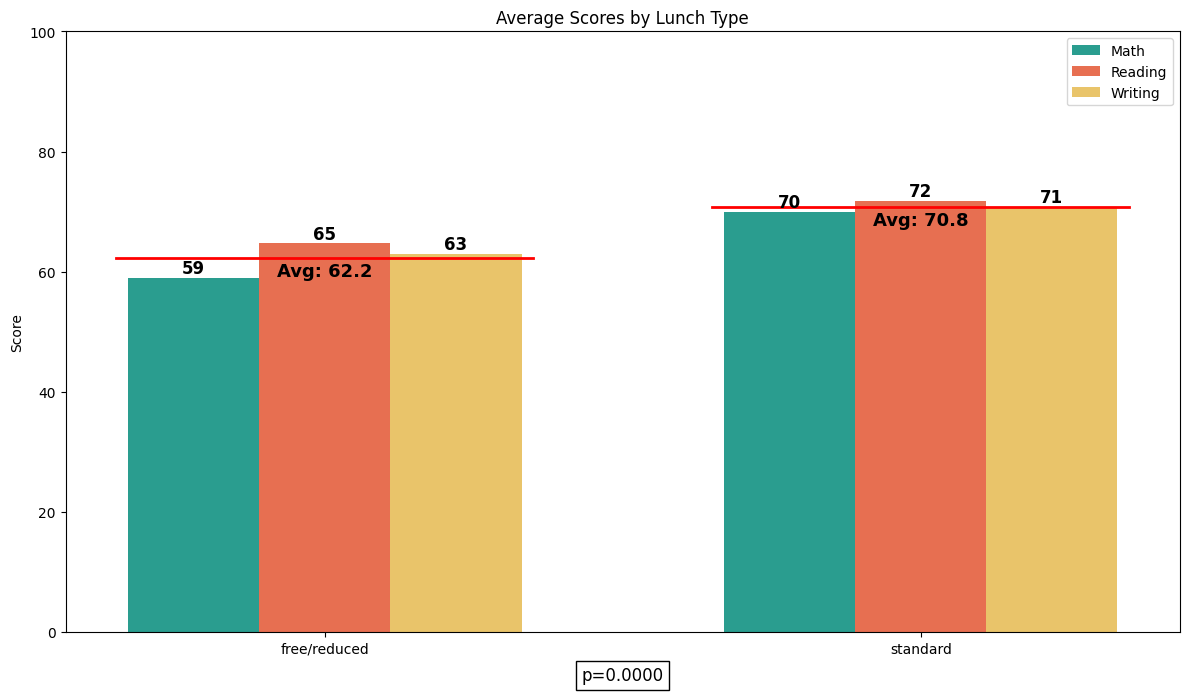

Saved → results/V3_Lunch_type_and_average_performance.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("results").mkdir(exist_ok=True)

# --- Normalize column names ---
df.columns = df.columns.astype(str).str.lower().str.replace(" ", "_").str.replace("/", "_")

# --- Detect columns ---
math_col = "math" if "math" in df.columns else "math_score"
read_col = "reading" if "reading" in df.columns else "reading_score"
write_col = "writing" if "writing" in df.columns else "writing_score"

# Lunch column
lunch_col = "lunch"

# --- Compute averages ---
grouped = df.groupby(lunch_col)[[math_col, read_col, write_col]].mean().round(1)

labels = grouped.index.tolist()
math_vals = grouped[math_col].values
read_vals = grouped[read_col].values
write_vals = grouped[write_col].values

# --- Plot settings ---
x = np.arange(len(labels))
width = 0.22

plt.figure(figsize=(12,7))

# Different colors (change here if you want)
colors = ["#2a9d8f", "#e76f51", "#e9c46a"]   # teal, coral, gold

bars1 = plt.bar(x - width, math_vals, width, label="Math", color=colors[0])
bars2 = plt.bar(x,         read_vals, width, label="Reading", color=colors[1])
bars3 = plt.bar(x + width, write_vals, width, label="Writing", color=colors[2])

# --- Add numbers on bars ---
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.8,
            f"{h:.0f}",
            ha="center",
            fontsize=12,
            fontweight="bold"
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# --- Average line per group ---
for i in range(len(labels)):
    avg_val = np.mean([math_vals[i], read_vals[i], write_vals[i]])

    plt.plot(
        [i - 0.35, i + 0.35],
        [avg_val, avg_val],
        color="red",
        linewidth=2
    )

    plt.text(
        i,
        avg_val - 3,
        f"Avg: {avg_val:.1f}",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

# --- Axis / titles ---
plt.xticks(x, labels)
plt.ylabel("Score")
plt.xlabel("Lunch Type")
plt.title("Average Scores by Lunch Type")

plt.legend()
plt.ylim(0, 100)

# Optional p-value text
plt.text(
    0.5,
    -8,
    "p=0.0000",
    ha="center",
    transform=plt.gca().transData,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.savefig("results/V3_Lunch_type_and_average_performance.png", dpi=300)
plt.show()

print("Saved → results/V3_Lunch_type_and_average_performance.png")

**D. V4 — Subject correlations (2 pts)**

a. Question: How strongly do the three subjects move together?

b. Chart: Correlation heatmap for math, reading, writing with annotated coefficients.


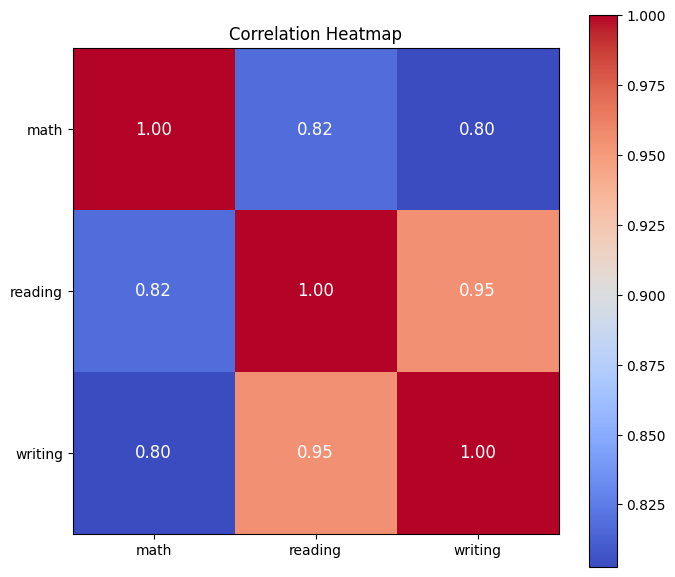

Saved: results/V4_Subject_correlations.png


In [9]:
# V4: Subject Correlations Heatmap

import matplotlib.pyplot as plt
import numpy as np

corr = df[["math", "reading", "writing"]].corr()

plt.figure(figsize=(7,6))

# Heatmap with different color style
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

# Add color bar
plt.colorbar()

# Labels
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.index)), corr.index)

# Add numbers inside boxes
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white", fontsize=12)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save
plt.savefig("results/V4_Subject_correlations.png")
plt.show()

print("Saved: results/V4_Subject_correlations.png")

**E. V5 — Math vs reading with trend lines by test prep (2 pts)**

a. Question: How strongly are math and reading scores associated, and do students who completed the test‑preparation course have a different slope in the math–reading relationship than those who did not?

b. Chart: Scatter plot with two straight best‑fit lines (one for each group: completed, none).

- i. X‑axis: reading score
- ii. Y‑axis: math score

c. Color: Points colored by test preparation course (legend must show the two
groups and each group’s n).

--- Visualization 5 ---


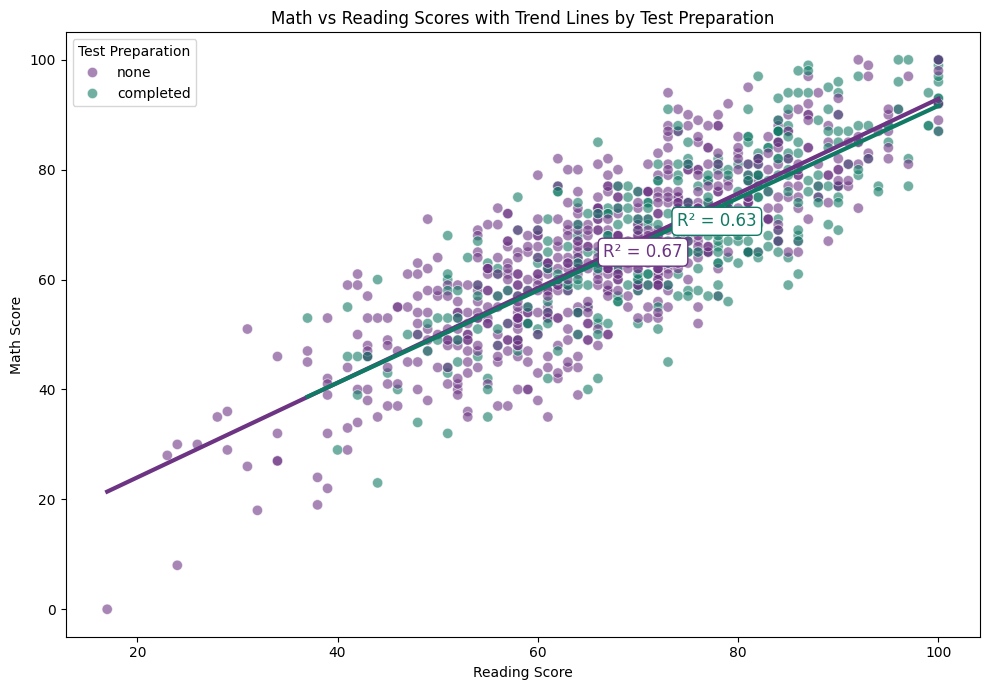

Saved: results/V5_Math_vs_Reading_with_Trend_Lines.png


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from pathlib import Path

print("--- Visualization 5 ---")

Path("results").mkdir(exist_ok=True)

x_col = "reading"
y_col = "math"
hue_col = "test_prep"

palette = {
    "none": "#6C3483",        # purple
    "completed": "#117A65"    # teal
}

plt.figure(figsize=(10, 7))

# Scatter
sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    hue=hue_col,
    palette=palette,
    alpha=0.6,
    s=55
)

# Trend lines + R²
for group, color in palette.items():
    sub = df[df[hue_col] == group]

    sns.regplot(
        data=sub,
        x=x_col,
        y=y_col,
        scatter=False,
        color=color,
        line_kws={"linewidth": 3},
        ci=None
    )

    # ---- Calculate R² ----
    r = np.corrcoef(sub[x_col], sub[y_col])[0, 1]
    r2 = r**2

    # Position text dynamically
    x_pos = sub[x_col].mean()
    y_pos = sub[y_col].mean()

    plt.text(
        x_pos,
        y_pos,
        f"R² = {r2:.2f}",
        color=color,
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.3")
    )

plt.title("Math vs Reading Scores with Trend Lines by Test Preparation")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.legend(title="Test Preparation")

plt.tight_layout()
plt.savefig("results/V5_Math_vs_Reading_with_Trend_Lines.png", dpi=300)
plt.show()

print("Saved: results/V5_Math_vs_Reading_with_Trend_Lines.png")

In [21]:
from google.colab import files

files.download("clean_data/clean_StudentPerformance.csv")

files.download("results/V1_Gender_Boxplots.png")
files.download("results/V2_Test_prep_impact_on_math.png")
files.download("results/V3_Lunch_type_and_average_performance.png")
files.download("results/V4_Subject_correlations.png")
files.download("results/V5_Math_vs_Reading_with_Trend_Lines.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>